## Main Calculation
Checkpoint results are stored in `outputs/logs/` at regular intervals, `save_interval`.


In [1]:
import sys
sys.path.append('../src')

In [2]:
# === Lightweight checkpoint I/O: no Orbax, no layout/sharding headaches ===
import os, io, json, numpy as np, jax
from flax.serialization import to_bytes, from_bytes

def _ensure_dir(p):
    os.makedirs(p, exist_ok=True)

def save_state_bytes(path, state):
    # Materialize to host; training still runs on GPU.
    state_cpu = jax.device_get(jax.tree_util.tree_map(lambda x: x, state))
    data = to_bytes(state_cpu)  # msgpack bytes
    tmp = path + ".tmp"
    with open(tmp, "wb") as f:
        f.write(data)
    os.replace(tmp, path)  # atomic rename

def load_state_bytes(path, dummy_state):
    with open(path, "rb") as f:
        data = f.read()
    # Restore into dummy_state’s structure/shapes/dtypes
    return from_bytes(dummy_state, data)

def save_loss_npz(path, loss_obj: dict):
    # Ensure directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    safe = {k: np.asarray(v) for k, v in loss_obj.items()}
    tmp = path + ".tmp"   # e.g., ".../loss_000000.npz.tmp"

    # Write EXACTLY to tmp (avoid np.savez adding another .npz)
    with open(tmp, "wb") as f:
        np.savez(f, **safe)

    os.replace(tmp, path)  # atomic rename to ".../loss_000000.npz"

def load_loss_npz(path):
    if not os.path.exists(path):
        return None
    with np.load(path) as npz:
        return {k: npz[k] for k in npz.files}

# Helper: ensure phi has same axis ordering as cryoET (try common transposes)
def ensure_phi_matches_cryo(phi, cryo):
    """If shapes already match, return phi. Otherwise try common axis permutations
    and transpose phi to match cryo. Raises ValueError if no match found."""
    if phi.shape == cryo.shape:
        return phi
    # Try common permutations (these cover typical (X,Y,Z) <-> (Z,Y,X) issues)
    perms = [(2,1,0), (0,2,1), (1,0,2)]
    for p in perms:
        try:
            t = phi.transpose(p)
        except Exception:
            continue
        if t.shape == cryo.shape:
            print(f"Transposed phi with perm {p} to match cryo shape {cryo.shape}")
            return t
    raise ValueError(f"Could not match phi shape {phi.shape} to cryo shape {cryo.shape}")


import os, re

# -------------------------
# Helper: find last saved step (msgpack)
# -------------------------
def find_last_state_path(ckpt_dir):
    last_path = None
    last_step = -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    return last_path, last_step


In [3]:
def adaptive_threshold(cryoET_data):
    return 0.6

In [ ]:
import jax
import jax.numpy as jnp
print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
# import pickle
# from flax.training import checkpoints
from pinn.utils import initial_loss
from tqdm.notebook import trange
import mrcfile
from pinn.model import (WEIGHT_IN, EPSILON, LEARNING_RATE)

# Initialize JAX random key
key = jax.random.PRNGKey(0)

state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")

with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET_data = mrc.data.astype(jnp.float32)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))

thre = adaptive_threshold(cryoET_data)

# Training Data
x_train = (jax.random.uniform(key, (NUM_COLLOCATION, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3

# Training loop
num_steps = 10000
save_interval = 100

checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")

# if checkpoint_dir already exists, remove it
if os.path.exists(checkpoint_dir):
    print(f"Checkpoint directory {checkpoint_dir} already exists. Removing it.")
    import shutil
    shutil.rmtree(checkpoint_dir)

loss0 = initial_loss(state, x_train, cryoET_data, thre)

_ensure_dir(checkpoint_dir)
save_state_bytes(os.path.join(checkpoint_dir, "state_000000.msgpack"), state)
save_loss_npz(os.path.join(checkpoint_dir, "loss_000000.npz"), loss0)
print("Saved step 0.")
print(sorted(os.listdir(checkpoint_dir))[:6])

loss_history = []

# for step in range(num_steps):
for step in trange(num_steps):
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data, thre)

    loss_history.append({
        "step": step + 1,
        "total_loss": loss_val,
        "data_loss": loss_data_val,
        "physics_loss": loss_physics_val
    })

    if (step+1) % save_interval == 0:

        # Convert history list-of-dicts → dict-of-arrays
        loss_history_np = {k: np.asarray([e[k] for e in loss_history]) for k in loss_history[0].keys()}

        step_tag = f"{step+1:06d}"
        save_state_bytes(os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack"), state)
        save_loss_npz(os.path.join(checkpoint_dir, f"loss_{step_tag}.npz"), loss_history_np)
        print(f"Saved step {step+1}")

        loss_history = []



In [4]:
def execute_pinn(data_dir, shape, l1, l2, NUM_COLLOCATION, sdf_pretrain):
    key = jax.random.PRNGKey(0)

    state, model = create_train_state(key, lambda_1=l1, lambda_2=l2, sdf_pretrain=sdf_pretrain, learning_rate=LEARNING_RATE)
    print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")

    mrc_file_path = f"../data/{data_dir}/{shape}.mrc"

    with mrcfile.open(mrc_file_path, permissive=True) as mrc:
            cryoET_data = mrc.data.astype(jnp.float32)

    thre = adaptive_threshold(cryoET_data)

    # Training Data
    x_train = (jax.random.uniform(key, (NUM_COLLOCATION, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3

    # Training loop
    num_steps = 10000
    save_interval = 100

    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{l1}_{l2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")

    # if checkpoint_dir already exists, remove it
    if os.path.exists(checkpoint_dir):
        print(f"Checkpoint directory {checkpoint_dir} already exists. Removing it.")
        import shutil
        shutil.rmtree(checkpoint_dir)

    loss0 = initial_loss(state, x_train, cryoET_data, thre)

    _ensure_dir(checkpoint_dir)
    save_state_bytes(os.path.join(checkpoint_dir, "state_000000.msgpack"), state)
    save_loss_npz(os.path.join(checkpoint_dir, "loss_000000.npz"), loss0)
    print("Saved step 0.")
    print(sorted(os.listdir(checkpoint_dir))[:6])

    loss_history = []

    # for step in range(num_steps):
    for step in trange(num_steps):
        state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data, thre)

        loss_history.append({
            "step": step + 1,
            "total_loss": loss_val,
            "data_loss": loss_data_val,
            "physics_loss": loss_physics_val
        })

        if (step+1) % save_interval == 0:

            # Convert history list-of-dicts → dict-of-arrays
            loss_history_np = {k: np.asarray([e[k] for e in loss_history]) for k in loss_history[0].keys()}

            step_tag = f"{step+1:06d}"
            save_state_bytes(os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack"), state)
            save_loss_npz(os.path.join(checkpoint_dir, f"loss_{step_tag}.npz"), loss_history_np)
            # print(f"Saved step {step+1}")

            loss_history = []

### Analysis

In [5]:
## make one combined image file

import os
import numpy as np
import jax
import jax.numpy as jnp
import mrcfile
import matplotlib.pyplot as plt
# from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history
from pinn.train import create_train_state
from pinn.model import (
    WEIGHT_IN, 
    EPSILON,
    LEARNING_RATE
) 

def analysis_basics(shape, lambda_1, lambda_2, mrc_file_path):

    num_layers = 2

    # steps_to_visualize = [0, 200, 600, 1000]
    # steps_series = list(range(0, 1001, 100))
    steps_to_visualize = [0, 100, 1000, 10000]
    steps_series = list(range(0, 10001, 100))

    # Load checkpoint data
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
    print(checkpoint_dir)

    # Build a dummy TrainState to give from_bytes() the structure/shapes (values will be overwritten)
    dummy_key = jax.random.PRNGKey(0)
    dummy_state, _ = create_train_state(
        dummy_key,
        lambda_1=lambda_1,
        lambda_2=lambda_2,
        sdf_pretrain=None,   # same arg you used in training; or None if not used
        learning_rate=LEARNING_RATE,
    )

    # 2) Load checkpoints safely
    checkpoint_data = {}
    for step in steps_series:
        step_tag = f"{step:06d}"
        state_path = os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack")
        loss_path  = os.path.join(checkpoint_dir, f"loss_{step_tag}.npz")
        if os.path.exists(state_path):
            # print(f"Loading {state_path}")
            restored_state = load_state_bytes(state_path, dummy_state)  # TrainState
            loss_blob = load_loss_npz(loss_path)                        # dict or None
            checkpoint_data[step] = {
                "state": {"params": restored_state.params},  # ← 여기서 wrap
                "loss": loss_blob,
            }

    # Load CryoET data
    with mrcfile.open(mrc_file_path, permissive=True) as mrc:
            cryoET_data = mrc.data.astype(jnp.float32)
    
    thre = adaptive_threshold(cryoET_data)

    # Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
    fig = plt.figure(figsize=(3*4, 12))

    # Row 1: visualize_cryoET_with_contours
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, i + 1)
        visualize_checkpoint_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, slice_index=cryoET_data.shape[0]/2, axis="z", thre=thre)
        if i == 0:
            ax.set_ylabel("CryoET + Contours")

    # Row 2: visualize_checkpoint_result
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 4 + i + 1)
        visualize_checkpoint_level_set(ax, step, checkpoint_data[step], cryoET_data=cryoET_data, slice_index=cryoET_data.shape[0]/2, axis="z")
        if i == 0:
            ax.set_ylabel("Level-set function")

    # Row 3: plot_3d_isosurface
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
        plot_3d_isosurface(ax, step, checkpoint_data[step])
        if i == 0:
            ax.set_zlabel("3D Isosurface", rotation=180)

    # Row 4: loss history
    assembled_loss = assemble_loss_history(checkpoint_data)
    ax = fig.add_subplot(4, 4, 12+1)
    plot_loss_history_ax(ax, assembled_loss)
    for i in [0,1,2]:
        ax = fig.add_subplot(4, 4, 12+i+2)
        plot_normalized_loss_history_ax(ax, i, assembled_loss)
        

    info_text = (
        f"GRID_SIZE = {cryoET_data.shape}, mask_thre = 0.8\n"
        f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = {LEARNING_RATE}\n"
        f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
        f"epsilon = 0.05, num_collocation = {NUM_COLLOCATION}"
    )

    fig.text(
        0.02, 1.08,  # (x, y) position in figure coordinates
        info_text,
        fontsize=12,
        ha='left',
        va='top'
    )

    plt.tight_layout()
    plt.show()

    # save the plot
    fig.savefig(os.path.join(checkpoint_dir, f"analysis1_{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}.png"), dpi=300, bbox_inches="tight")

In [6]:
import jax
import jax.numpy as jnp
print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.utils import initial_loss
from tqdm.notebook import trange
import mrcfile
from pinn.model import (WEIGHT_IN, EPSILON, LEARNING_RATE)

data_dir = "Jake_Cropped"
shape = "74_S1"
mask_shape = "74_S1"
mrc_file_path = f"../data/{data_dir}/{shape}.mrc"
sdf_pretrain = "sphere"
NUM_COLLOCATION = 1000


jax: 0.7.2
devices: [CudaDevice(id=0)]


In [ ]:
# Change lambda_1
lambda_1 = 3000000
lambda_2 = 0
execute_pinn(data_dir, shape, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain)
analysis_basics(shape, lambda_1, lambda_2, mrc_file_path)

lambda_1 = 3000000
lambda_2 = 100
execute_pinn(data_dir, shape, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain)
analysis_basics(shape, lambda_1, lambda_2, mrc_file_path)

lambda_1 = 3000000
lambda_2 = 200
execute_pinn(data_dir, shape, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain)
analysis_basics(shape, lambda_1, lambda_2, mrc_file_path)

Pretraining the network using SDF...
Using lambda_1: 3000000, lambda_2: 0
Saved step 0.
['loss_000000.npz', 'state_000000.msgpack']


  0%|          | 0/10000 [00:00<?, ?it/s]

/home/minisemin/matsulab/pinn-exploration-model/outputs/logs/74_S1/lambda_3000000_0_weightIn_0.5_epsilon_0.05_Learning_0.001


TypeError: plot_3d_isosurface() missing 1 required positional argument: 'shape'

# Confusion Matrix

In [ ]:
import numpy as np
from skimage.measure import marching_cubes
from scipy.spatial import cKDTree

def calculate_accuracy_precision_recall(
        phi_zyx,
        mask_zyx,
        eps=EPSILON,
        spacing=None,       # (d0, d1, d2) for the given array order (same for phi & mask). If None, assume normalized [-1,1].
        tau_factor = 1.5,   # surface tolerance τ = tau_factor * ε
        sigma_factor = 1.0, # soft Gaussian σ = sigma_factor * ε
        tri_tau_factor=2.0,        # soft Triangular τ = tri_tau_factor*ε
        mask_level=0.5,            # GT(mask) iso-level for surface
        return_meshes=False,       
):
    """
    Compute membrane metrics from a signed field φ and a binary GT mask.

    Inputs
    ------
    phi   : ndarray (same shape as mask). φ(x) where φ=0 is membrane; φ<0 interior (convention).
    mask  : ndarray of {0,1} or [0,1]. 1 = interior (organellar volume), 0 = background.
    epsilon : float, phase-field ε (same coordinate system as phi).
    spacing : tuple/list of 3 floats giving voxel size along each axis in the SAME order as arrays.
              If None, assumes normalized box [-1,1] per axis, so di = 2/ni.
    tau_factor, sigma_factor, tri_tau_factor : scalars to scale ε for tolerance/kernel widths.
    mask_level : marching-cubes isovalue for the GT mask surface (usually 0.5).
    return_meshes : whether to also return the marching-cubes meshes.

    Returns
    -------
    metrics : dict with keys:
        - volume_* : Dice/IoU/Precision/Recall/Accuracy for φ<=0 vs mask
        - surface_* : tau, precision, recall, f1, assd, hd95 (distance-based; anisotropy-aware)
        - soft_gauss_* : soft precision/recall/F1/IoU (Gaussian kernel on |φ|)
        - soft_tri_*   : soft precision/recall/F1/IoU (Triangular kernel on |φ|)
      (+ optional 'meshes' if return_meshes=True)
    """
    phi_np  = np.asarray(phi_zyx)
    mask_np = np.asarray(mask_zyx).astype(np.float32)

    assert phi_np.shape == mask_np.shape, "phi and mask must have the same shape"
    nz, ny, nx = phi_np.shape  # just names; array order is whatever you pass in

    # --- spacing (anisotropy-aware) ---
    if spacing is None:
        # assume normalized [-1,1] along each axis of the array order:
        d0 = 2.0 / nz
        d1 = 2.0 / ny
        d2 = 2.0 / nx
        spacing = (d0, d1, d2)
    else:
        assert len(spacing) == 3, "spacing must have 3 elements"
        d0, d1, d2 = map(float, spacing)

    # =========================
    # A) Volume segmentation metrics (φ<=0 vs mask)
    # =========================
    pred_inside = (phi_np <= 0).astype(np.uint8)
    gt_inside   = (mask_np >= 0.5).astype(np.uint8)

    TP = np.logical_and(pred_inside == 1, gt_inside == 1).sum()
    FP = np.logical_and(pred_inside == 1, gt_inside == 0).sum()
    FN = np.logical_and(pred_inside == 0, gt_inside == 1).sum()
    TN = np.logical_and(pred_inside == 0, gt_inside == 0).sum()
    N  = gt_inside.size

    dice_vol = (2*TP) / (2*TP + FP + FN + eps)
    iou_vol  = TP / (TP + FP + FN + eps)
    prec_vol = TP / (TP + FP + eps)
    rec_vol  = TP / (TP + FN + eps)
    acc_vol  = (TP + TN) / (N + eps)

    # =========================
    # B) Surface metrics: τ-Precision/Recall + ASSD/HD95
    # =========================
    # Build surfaces with anisotropic spacing
    verts_pred, faces_pred, _, _ = marching_cubes(phi_np.astype(np.float32), level=0.0, spacing=spacing, allow_degenerate=False)
    verts_gt,   faces_gt,   _, _ = marching_cubes(mask_np.astype(np.float32), level=mask_level, spacing=spacing, allow_degenerate=False)

    # KD-tree distances (same coordinate system → absolute positions cancel any common shift)
    t_pred = cKDTree(verts_pred); t_gt = cKDTree(verts_gt)
    d_pred_to_gt, _ = t_gt.query(verts_pred, k=1)
    d_gt_to_pred, _ = t_pred.query(verts_gt,   k=1)

    # Tolerance τ in the SAME units as 'spacing' and marching-cubes coordinates.
    # If spacing was normalized (2/N), then ε is also in that normalized unit; OK to multiply directly.
    tau = float(tau_factor) * float(epsilon)

    prec_surf = (d_pred_to_gt <= tau).mean() if len(d_pred_to_gt) else 0.0
    rec_surf  = (d_gt_to_pred  <= tau).mean() if len(d_gt_to_pred)  else 0.0
    f1_surf   = 2*prec_surf*rec_surf/(prec_surf+rec_surf+eps)

    assd = 0.5 * (d_pred_to_gt.mean() + d_gt_to_pred.mean())
    # robust Hausdorff-95 (symmetric)
    hd95 = max(np.percentile(d_pred_to_gt, 95), np.percentile(d_gt_to_pred, 95))

    # =========================
    # C) Soft-kernel (on |φ|): Gaussian & Triangular
    # =========================
    # kernel widths in the SAME coordinate system as φ (no anisotropy handling needed)
    sigma = float(sigma_factor) * float(epsilon)
    tau_soft = float(tri_tau_factor) * float(epsilon)

    w_gauss = np.exp(- (phi_np / (sigma + eps))**2 )
    w_tri   = np.clip(1.0 - np.abs(phi_np) / (tau_soft + eps), 0.0, 1.0)

    M = (mask_np >= 0.5).astype(np.float32)

    # Gaussian soft metrics
    I = (M * w_gauss).sum()
    P = I / (w_gauss.sum() + eps)
    R = I / (M.sum() + eps)
    F1 = 2*P*R/(P+R+eps)
    IoU = I / (M.sum() + w_gauss.sum() - I + eps)

    # Triangular soft metrics
    I_t = (M * w_tri).sum()
    P_t = I_t / (w_tri.sum() + eps)
    R_t = I_t / (M.sum() + eps)
    F1_t = 2*P_t*R_t/(P_t+R_t+eps)
    IoU_t = I_t / (M.sum() + w_tri.sum() - I_t + eps)

    metrics = {
        # Volume
        "volume_dice": float(dice_vol),
        "volume_iou":  float(iou_vol),
        "volume_precision": float(prec_vol),
        "volume_recall":    float(rec_vol),
        "volume_accuracy":  float(acc_vol),

        # Surface (distance-based)
        "surface_tau": float(tau),
        "surface_precision": float(prec_surf),
        "surface_recall":    float(rec_surf),
        "surface_f1":        float(f1_surf),
        "surface_assd":      float(assd),
        "surface_hd95":      float(hd95),

        # Soft (Gaussian)
        "soft_gauss_sigma": float(sigma),
        "soft_gauss_precision": float(P),
        "soft_gauss_recall":    float(R),
        "soft_gauss_f1":        float(F1),
        "soft_gauss_iou":       float(IoU),

        # Soft (Triangular)
        "soft_tri_tau": float(tau_soft),
        "soft_tri_precision": float(P_t),
        "soft_tri_recall":    float(R_t),
        "soft_tri_f1":        float(F1_t),
        "soft_tri_iou":       float(IoU_t),
    }

    if return_meshes:
        metrics["meshes"] = {
            "pred": (verts_pred, faces_pred),
            "gt":   (verts_gt,   faces_gt),
        }
    return metrics


In [ ]:
import os
import numpy as np
import jax, jax.numpy as jnp
import mrcfile

from pinn.grid import phi_on_cryo_grid_xyz
from pinn.plot import _to_zyx
from pinn.train import create_train_state
from pinn.model import PINN, EPSILON, LEARNING_RATE

# -----------------------------
# 0) 경로 & 하이퍼파라미터
# -----------------------------
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"
checkpoint_dir = os.path.abspath(
    f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}"
)

# -----------------------------
# 1) GT mask 로드 (+ spacing 준비)
# -----------------------------
with mrcfile.open(mask_file_path, permissive=True) as mrc:
    mask = np.asarray(mrc.data, dtype=np.float32)   # (Z,Y,X)
    # (A) 정규화 spacing: [-1,1] 가정
    Z_len, Y_len, X_len = mask.shape
    spacing_norm = (2.0 / Z_len, 2.0 / Y_len, 2.0 / X_len)  # (dz, dy, dx)

    # (B) 물리 spacing (있다면 더 정확)
    # cella는 전체 길이(Å), nx,ny,nz는 voxel 수
    ax, ay, az = float(mrc.header.cella.x), float(mrc.header.cella.y), float(mrc.header.cella.z)
    nx, ny, nz = int(mrc.header.nx),        int(mrc.header.ny),        int(mrc.header.nz)
    spacing_phys = (az / nz, ay / ny, ax / nx)  # (dz, dy, dx) 물리단위(Å/voxel)

# 원하는 쪽 선택: spacing=None(정규화로 자동 처리) 또는 spacing=spacing_norm, spacing=spacing_phys
# spacing을 None으로 주면 함수 내부에서 (2/N) 정규화 spacing을 자동 사용합니다.
SPACING = None            # 가장 간단
# SPACING = spacing_norm  # 정규화 spacing을 명시하고 싶을 때
# SPACING = spacing_phys  # 물리단위로 평가할 때(ε도 물리단위여야 일관)

# -----------------------------
# 2) 체크포인트 로드 (하나/여러개)
# -----------------------------
# 더미 state 틀 만들기
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=None,
    learning_rate=LEARNING_RATE,
)

# (a) 마지막 체크포인트 하나만 쓰기
last_state_path, num_steps = find_last_state_path(checkpoint_dir)
assert last_state_path is not None, "No state_*.msgpack found."
restored_state = load_state_bytes(last_state_path, dummy_state)  # TrainState
params_vars = restored_state.params  # ← 주의: 당신 코드베이스에선 apply에 'params_vars' 자체를 넘깁니다.

# (b) 여러 스텝 비교하고 싶다면:
# steps_series = [0, 10000, 20000, ...]
# checkpoint_data = {}
# for step in steps_series:
#     p = os.path.join(checkpoint_dir, f"state_{step:06d}.msgpack")
#     if os.path.exists(p):
#         st = load_state_bytes(p, dummy_state)
#         checkpoint_data[step] = {"params": st.params}
# # 사용 시: params_vars = checkpoint_data[step]["params"]

# -----------------------------
# 3) φ 평가 (cryo grid에 맞춰 xyz→zyx로 정렬)
# -----------------------------
model = PINN()

# Flax의 apply 서명에 맞게: (당신 코드 기준) model.apply(params_vars, x)
def phi_fn(x):
    # x: (..., 3) in normalized coords [-1,1]^3
    return model.apply(params_vars, x.reshape(-1, 3)).reshape(x.shape[:-1])

# cryo grid에 맞춰 φ를 (X,Y,Z) 순서로 샘플링
phi_xyz = phi_on_cryo_grid_xyz(phi_fn, shape=shape, lo=-1.0, hi=1.0)
# skimage/marching_cubes는 (Z,Y,X)가 흔하므로 변환
phi_zyx = _to_zyx(np.array(phi_xyz))          # numpy float64
phi_zyx = np.array(phi_zyx, dtype=np.float32, order="C")  # C contiguous float32 권장

# mask는 이미 (Z,Y,X)임
mask_zyx = np.array(mask, dtype=np.float32, order="C")

# -----------------------------
# 4) 지표 계산 (정규화/물리 spacing 중 택1)
# -----------------------------
metrics = calculate_accuracy_precision_recall(   # = evaluate_membrane_metrics
    phi_zyx,                   # (Z,Y,X)
    mask_zyx,                  # (Z,Y,X), 1=interior
    epsilon=EPSILON,           # φ의 좌표계 단위와 일치해야 함
    spacing=SPACING,           # None이면 [-1,1] 정규화 spacing 자동
    tau_factor=1.5,            # τ ≈ 1.5 ε
    sigma_factor=1.0,          # Gaussian σ ≈ 1.0 ε
    tri_tau_factor=2.0,        # Triangular τ ≈ 2.0 ε
    mask_level=0.5,
    return_meshes=False,
)

# -----------------------------
# 5) 결과 출력
# -----------------------------
for k, v in metrics.items():
    if k != "meshes":
        print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")


#### Physics Analysis

In [ ]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
import mrcfile
import jax.numpy as jnp
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_physics_loss,
)
from pinn.train import create_train_state   
from pinn.utils import assemble_loss_history
import jax
from pinn.model import (EPSILON, WEIGHT_IN, LEARNING_RATE)

# lambda_1 = 5000000
# lambda_2 = 1
num_layers = 2
# shape = "multi"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 2000, 6000, 10000]
# steps_to_visualize = [0, 1000, 6000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")

# Dummy state (template)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=None,
    learning_rate=LEARNING_RATE,
)

checkpoint_data = {}
for step in steps_to_visualize:
    step_tag = f"{step:06d}"
    state_path = os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack")
    loss_path  = os.path.join(checkpoint_dir, f"loss_{step_tag}.npz")
    if os.path.exists(state_path):
        restored_state = load_state_bytes(state_path, dummy_state)
        loss_blob = load_loss_npz(loss_path)
        checkpoint_data[step] = {"state": restored_state, "loss": loss_blob}

with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET_data = mrc.data.astype(jnp.float32)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


Z = cryoET_data.shape[0]

# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    checkpoint_data[step] = {
    "state": {"params": restored_state.params},
    "loss": loss_blob, 
    }
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="data",
                           slice_index=int(Z/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    if i == 0:
        ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           slice_index=int(Z/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {cryoET_data.shape}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = {LEARNING_RATE}\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {EPSILON}, num_collocation = {NUM_COLLOCATION}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'learning_rate' is not defined

In [ ]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from pinn.train import create_train_state
from flax.training import checkpoints
import imageio
import re
from pinn.model import (WEIGHT_IN, EPSILON, LEARNING_RATE)

steps_to_visualize = list(range(0, 30001, 1000))
log_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/")
frame_dir = os.path.join(log_dir, f"frames")

# Dummy template
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=None,
    learning_rate=LEARNING_RATE,
)

def save_isosurface_frame(step, checkpoint, save_dir, grid_size=None):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir, output="movie.mp4", fps=12, start=0, end=30000):
    pattern = re.compile(r"frame_(\d+)\.png")
    frames = []
    for fname in os.listdir(frame_dir):
        m = pattern.match(fname)
        if m:
            idx = int(m.group(1))
            if start <= idx <= end:
                frames.append((idx, os.path.join(frame_dir, fname)))
    frames.sort(key=lambda x: x[0])
    with imageio.get_writer(output, fps=fps) as writer:
        for _, fp in frames:
            writer.append_data(imageio.imread(fp))

# Render frames
for step in steps_to_visualize:
    step_tag = f"{step:06d}"
    state_path = os.path.join(log_dir, f"state_{step_tag}.msgpack")
    if os.path.exists(state_path):
        restored_state = load_state_bytes(state_path, dummy_state)
        print(f"saving step {step}")
        # match the dict structure expected by plot_3d_isosurface
        # save_isosurface_frame(step, {"state": restored_state}, save_dir=frame_dir, grid_size=GRID_SIZE)
        # wrap TrainState -> old dict shape expected by plot_3d_isosurface
        save_isosurface_frame(step, {"state": {"params": restored_state.params}}, save_dir=frame_dir, grid_size=Z)

# Make the movie
output = os.path.abspath(os.path.join(frame_dir, f"{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}.mp4"))
make_movie_from_frames(frame_dir=frame_dir, output=output)
print("Wrote:", output)


### Compare the result with the segmented mask

Transposed phi with perm (2, 1, 0) to match cryo shape (154, 180, 180)
[step 10000] band=0.150
Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000 | Accuracy: 0.0000
ASSD: 0.0619 | HD95: 0.3532 (in normalized units)


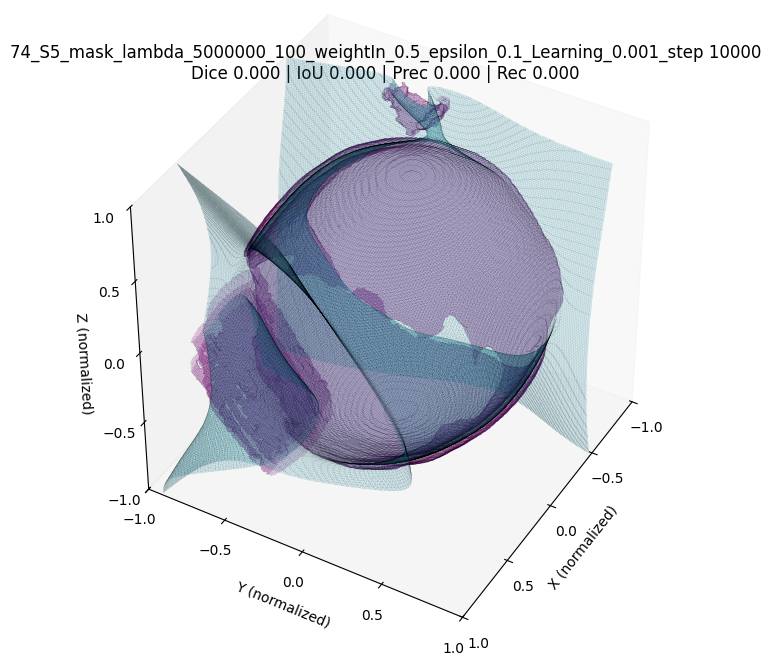

In [ ]:
import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.spatial import cKDTree  # optional, for surface distance metrics

from pinn.cryoet_io import load_mrc_data
from pinn.train import create_train_state
from pinn.model import (PINN, WEIGHT_IN, EPSILON, LEARNING_RATE)

# Load the final data and the segmented mask
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

# pick a band around phi=0 to approximate the membrane thickness in voxels
band = 1.5 * EPSILON  # you can tune: 1.0~2.0 * epsilon is typical

state_path, num_steps = find_last_state_path(checkpoint_dir)
assert state_path is not None, "No state_*.msgpack found."

# -------------------------
# Restore model
# -------------------------
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=None,
    learning_rate=LEARNING_RATE,
)
restored_state = load_state_bytes(state_path, dummy_state)  # TrainState with .params as you saved
params = restored_state.params

# Build model
model = PINN()  # your class defaults: hidden_dim=16, num_frequencies=10

# -------------------------
# Load ground-truth mask and evaluate φ on the grid
# -------------------------
# mask_data = load_mrc_data(mask_file_path, grid_size=GRID_SIZE)  # float in {0,1} or [0,1]
with mrcfile.open(mask_file_path, permissive=True) as mrc:
        mask = mrc.data.astype(jnp.float32)

# Build per-axis coordinate arrays from the mask (mask is shaped (Z, Y, X))
Z_len, Y_len, X_len = mask.shape
x = jnp.linspace(-1, 1, X_len)
y = jnp.linspace(-1, 1, Y_len)
z = jnp.linspace(-1, 1, Z_len)
# Meshgrid with 'ij' so Xg.shape == (len(x), len(y), len(z)) == (X_len, Y_len, Z_len)
Xg, Yg, Zg = jnp.meshgrid(x, y, z, indexing="ij")
points = jnp.stack([Xg.ravel(), Yg.ravel(), Zg.ravel()], axis=-1)

# IMPORTANT: your TrainState.params is a full variables dict (incl. 'params'),
# and your code elsewhere uses model.apply(params, x). We do the same:
phi = model.apply(params, points)
# Reshape to (X_len, Y_len, Z_len) to match the meshgrid ordering used above
phi = phi.reshape((X_len, Y_len, Z_len))
# Ensure phi ordering matches the mask/cryo convention; transpose if needed
phi = ensure_phi_matches_cryo(phi, mask)


# -------------------------
# Predicted membrane mask from a narrow band: |φ| ≤ band
# -------------------------
pred_mask = (np.abs(np.asarray(phi)) <= band).astype(np.uint8)


# -------------------------
# Metrics (membrane class)
# -------------------------
TP = np.logical_and(pred_mask == 1, mask == 1).sum()
FP = np.logical_and(pred_mask == 1, mask == 0).sum()
FN = np.logical_and(pred_mask == 0, mask == 1).sum()
TN = np.logical_and(pred_mask == 0, mask == 0).sum()
N  = mask.size

dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
iou  = TP / (TP + FP + FN + 1e-8)
prec = TP / (TP + FP + 1e-8)
rec  = TP / (TP + FN + 1e-8)
acc  = (TP + TN) / N

print(f"[step {num_steps}] band={band:.3f}")
print(f"Dice: {dice:.4f} | IoU: {iou:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | Accuracy: {acc:.4f}")


# -------------------------
# (Optional) surface distance metrics using meshes
# -------------------------
def surface_from_volume(vol, level, spacing):
    """
    Make a writable, C-contiguous float32 NumPy array for skimage.marching_cubes.
    Apply the SAME orientation (transpose) to all volumes if you choose to.
    """
    # Bring to host, ensure dtype/contiguity, and make it writable
    v = np.array(jax.device_get(vol), dtype=np.float32, order="C", copy=True)
    # If elsewhere you used a transpose (e.g., phi = phi.T), apply it here to BOTH
    # v = v.transpose(2, 1, 0)  # <- only if you decide to reorient consistently

    verts, faces, _, _ = marching_cubes(
        v,
        level=level,
        spacing=spacing,
        allow_degenerate=False,   # reduces weird triangles
        method="lewiner",
    )
    return verts, faces


# marching_cubes expects spacing matching the axes of the volume passed (Z, Y, X)
spacing = (2.0 / float(Z_len), 2.0 / float(Y_len), 2.0 / float(X_len))

# Predicted surface at φ=0, GT surface at mask=0.5
pred_verts, pred_faces = surface_from_volume(phi,   level=0.0, spacing=spacing)
gt_verts,   gt_faces   = surface_from_volume(mask,  level=0.5, spacing=spacing)

# shift to [-1,1]^3 to match your plotting convention
pred_verts -= 1.0
gt_verts   -= 1.0


# Average Symmetric Surface Distance (ASSD) & Hausdorff (optional)
try:
    t_pred = cKDTree(pred_verts); t_gt = cKDTree(gt_verts)
    d_pred_to_gt, _ = t_gt.query(pred_verts, k=1)
    d_gt_to_pred, _ = t_pred.query(gt_verts, k=1)
    assd = 0.5 * (d_pred_to_gt.mean() + d_gt_to_pred.mean())
    hd95 = max(np.percentile(d_pred_to_gt, 95), np.percentile(d_gt_to_pred, 95))
    print(f"ASSD: {assd:.4f} | HD95: {hd95:.4f} (in normalized units)")
except Exception as e:
    print("Surface distance metrics skipped (SciPy missing?):", e)

# -------------------------
# 3D overlay visualization (matplotlib)
# -------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# GT surface (magenta)
mesh_gt = Poly3DCollection(gt_verts[gt_faces], alpha=0.15, facecolor=(0.8, 0.2, 0.8), edgecolor='k', linewidth=0.1)
ax.add_collection3d(mesh_gt)

# Pred surface (cyan)
mesh_pred = Poly3DCollection(pred_verts[pred_faces], alpha=0.15, facecolor=(0.2, 0.8, 0.9), edgecolor='k', linewidth=0.1)
ax.add_collection3d(mesh_pred)

ax.set_xlabel("X (normalized)")
ax.set_ylabel("Y (normalized)")
ax.set_zlabel("Z (normalized)")

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_box_aspect((1,1,1))
ax.view_init(elev=40, azim=30)

ax.set_title(f"{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}_step {num_steps}\n"
             f"Dice {dice:.3f} | IoU {iou:.3f} | Prec {prec:.3f} | Rec {rec:.3f}",
             y=0.95)
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks); ax.set_yticks(ticks); ax.set_zticks(ticks)
ax.grid(False)
plt.show()

In [28]:
# --- Overlay a specific z-slice: CryoET, GT mask, and predicted phi=0 contour ---

import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt

from pinn.cryoet_io import load_mrc_data
from pinn.train import create_train_state
from pinn.model import PINN

# -----------------------------
# Config: choose the slice
# -----------------------------
# Option A: pick normalized z in [-1, 1]
z_value = 0.0                       # e.g., mid-plane; change to -0.5, 0.25, etc.

# Option B: OR pick a voxel index directly (0..GRID_SIZE-1); set to None to use z_value
slice_index_override = None         # e.g., 32

# Optional: also show the predicted "narrow band" |phi| <= band as a semi-transparent overlay
band = 1.5 * EPSILON                # tune 1.0~2.0 * epsilon if you want to see a band

# -----------------------------
# Paths
# -----------------------------
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
# mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

# -----------------------------
# Helpers
# -----------------------------
def find_last_state_path(ckpt_dir):
    last_path, last_step = None, -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    if last_path is None:
        raise FileNotFoundError(f"No state_*.msgpack in {ckpt_dir}")
    return last_path, last_step

def z_to_index(z, grid_z):
    # map normalized z in [-1,1] -> voxel index [0..grid_z-1]
    idx = int(np.round((float(z) + 1.0) * 0.5 * (grid_z - 1)))
    return int(np.clip(idx, 0, grid_z - 1))

# -----------------------------
# Restore model (latest checkpoint)
# -----------------------------
state_path, num_steps = find_last_state_path(checkpoint_dir)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(dummy_key, lambda_1=lambda_1, lambda_2=lambda_2,
                                    sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
restored_state = load_state_bytes(state_path, dummy_state)   # TrainState
params = restored_state.params
model = PINN()  # your defaults: hidden_dim=16, num_frequencies=10

# -----------------------------
# Load data and evaluate phi
# -----------------------------
with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET = mrc.data.astype(jnp.float32)         # float [0,1], shape (Z, Y, X)
with mrcfile.open(mask_file_path, permissive=True) as mrc:
        gt_mask = mrc.data.astype(jnp.float32)

Z, Y, X = cryoET.shape
# Create linspaces for each axis (note cryoET is (Z, Y, X))
x = jnp.linspace(-1, 1, X)
y = jnp.linspace(-1, 1, Y)
z = jnp.linspace(-1, 1, Z)

# Build coordinate grids shaped (Z, Y, X) to match cryoET ordering.
# We keep the stacking order (x, y, z) for the model but shape the grids so
# when reshaped the phi array has shape (Z, Y, X) and aligns with cryoET.
Zg, Yg, Xg = jnp.meshgrid(z, y, x, indexing="ij")  # shape (Z, Y, X)
pts = jnp.stack([Xg.ravel(), Yg.ravel(), Zg.ravel()], axis=-1)  # (N,3) in (x,y,z)

phi = model.apply(params, pts).reshape((Z, Y, X))  # match cryoET ordering
# Ensure phi ordering really matches cryoET; transpose if needed
phi = ensure_phi_matches_cryo(phi, cryoET)

# Precompute axes helpers (x corresponds to columns, y to rows)
x_coords = np.linspace(-1, 1, X)
y_coords = np.linspace(-1, 1, Y)
extent  = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
voxel_ticks_x = np.linspace(0, X-1, 5).astype(int)
voxel_ticks_y = np.linspace(0, Y-1, 5).astype(int)
norm_ticks_x  = np.linspace(-1, 1, 5)
norm_ticks_y  = np.linspace(-1, 1, 5)

# -----------------------------
# Pick slice (z)
# -----------------------------
if slice_index_override is None:
    k = z_to_index(z_value, Z)
else:
    k = int(np.clip(slice_index_override, 0, Z-1))

# -----------------------------
# Render frames
# -----------------------------
for k in [k]:
    cryo_sl = np.asarray(cryoET[k, :, :])
    mask_sl = np.asarray(gt_mask[k, :, :])
    phi_sl  = np.asarray(phi[k, :, :])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    # (1) CryoET
    axes[0].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[0].set_title(f"CryoET (z={k}/{Z-1})")
    axes[0].set_xlabel("X (voxels)"); axes[0].set_ylabel("Y (voxels)")
    axes[0].set_xticks(norm_ticks_x); axes[0].set_xticklabels(voxel_ticks_x)
    axes[0].set_yticks(norm_ticks_y); axes[0].set_yticklabels(voxel_ticks_y)

    # (2) GT overlay
    axes[1].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[1].imshow(np.ma.masked_where(mask_sl == 0, mask_sl),
                   cmap="autumn", origin="lower", extent=extent, alpha=0.45)
    axes[1].contour(x_coords, y_coords, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[1].set_title("CryoET + GT mask")
    axes[1].set_xlabel("X (voxels)"); axes[1].set_ylabel("Y (voxels)")
    axes[1].set_xticks(norm_ticks_x); axes[1].set_xticklabels(voxel_ticks_x)
    axes[1].set_yticks(norm_ticks_y); axes[1].set_yticklabels(voxel_ticks_y)

    # (3) Combined: GT + predicted φ=0 (and the narrow band)
    axes[2].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)

    # Optional predicted band overlay: |phi| <= band
    if band is not None and band > 0:
        pred_band = (np.abs(phi_sl) <= band).astype(np.uint8)
        axes[2].imshow(np.ma.masked_where(pred_band == 0, pred_band),
                       cmap="cool", origin="lower", extent=extent, alpha=0.35)

    # GT contour (magenta) + φ=0 contour (cyan)
    axes[2].contour(x_coords, y_coords, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[2].contour(x_coords, y_coords, phi_sl,  levels=[0.0], colors="cyan",    linewidths=1.6)
    axes[2].set_title(f"CryoET + GT (magenta) + Pred φ=0 (cyan)\nstep {num_steps}")
    axes[2].set_xlabel("X (voxels)"); axes[2].set_ylabel("Y (voxels)")
    axes[2].set_xticks(norm_ticks_x); axes[2].set_xticklabels(voxel_ticks_x)
    axes[2].set_yticks(norm_ticks_y); axes[2].set_yticklabels(voxel_ticks_y)

    plt.show()


Pretraining the network using SDF...


NameError: name 'mask_file_path' is not defined

In [31]:
# === Movie: sweep through z, showing CryoET + GT + Pred overlays ===
import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import imageio.v2 as imageio  # same API as imageio.get_writer
from pinn.cryoet_io import load_mrc_data
from pinn.train import create_train_state
from pinn.model import PINN

# -----------------------------
# Config
# -----------------------------
band_factor = 1.5        # show predicted |phi| <= band_factor * epsilon as a semi-transparent band
fps         = 12
z_start, z_end, z_step = 0, None, 1   # None => last index; step controls stride (e.g., 2 to skip)
movie_name  = f"overlay_z_sweep_{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}.mp4"

checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

frames_dir = os.path.join(checkpoint_dir, "frames_overlay_z")
os.makedirs(frames_dir, exist_ok=True)
movie_path = os.path.join(checkpoint_dir, movie_name)

# -----------------------------
# Helpers
# -----------------------------
def find_last_state_path(ckpt_dir):
    last_path, last_step = None, -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    if last_path is None:
        raise FileNotFoundError(f"No state_*.msgpack in {ckpt_dir}")
    return last_path, last_step

# -----------------------------
# Restore model (latest checkpoint)
# -----------------------------
state_path, num_steps = find_last_state_path(checkpoint_dir)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(dummy_key, lambda_1=lambda_1, lambda_2=lambda_2,
                                    sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
restored_state = load_state_bytes(state_path, dummy_state)   # TrainState
params = restored_state.params
model = PINN()

# -----------------------------
# Load data and evaluate phi
# -----------------------------
with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET = mrc.data.astype(jnp.float32)
with mrcfile.open(mask_file_path, permissive=True) as mrc:
        gt_mask = mrc.data.astype(jnp.float32)          

Z, Y, X = cryoET.shape
# Create linspaces for each axis (note cryoET is (Z, Y, X))
x = jnp.linspace(-1, 1, X)
y = jnp.linspace(-1, 1, Y)
z = jnp.linspace(-1, 1, Z)

# Build coordinate grids shaped (Z, Y, X) to match cryoET ordering.
# We keep the stacking order (x, y, z) for the model but shape the grids so
# when reshaped the phi array has shape (Z, Y, X) and aligns with cryoET.
Zg, Yg, Xg = jnp.meshgrid(z, y, x, indexing="ij")  # shape (Z, Y, X)
pts = jnp.stack([Xg.ravel(), Yg.ravel(), Zg.ravel()], axis=-1)  # (N,3) in (x,y,z)

phi = model.apply(params, pts).reshape((Z, Y, X))  # match cryoET ordering
# Ensure phi ordering really matches cryoET; transpose if needed
phi = ensure_phi_matches_cryo(phi, cryoET)

# Precompute axes helpers (x corresponds to columns, y to rows)
x_coords = np.linspace(-1, 1, X)
y_coords = np.linspace(-1, 1, Y)
extent  = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
voxel_ticks_x = np.linspace(0, X-1, 5).astype(int)
voxel_ticks_y = np.linspace(0, Y-1, 5).astype(int)
norm_ticks_x  = np.linspace(-1, 1, 5)
norm_ticks_y  = np.linspace(-1, 1, 5)

band = band_factor * EPSILON

# -----------------------------
# Render frames
# -----------------------------
if z_end is None:
    z_end = Z - 1
z_indices = list(range(int(z_start), int(z_end) + 1, int(z_step)))

for k in z_indices:
    cryo_sl = np.asarray(cryoET[k, :, :])
    mask_sl = np.asarray(gt_mask[k, :, :])
    phi_sl  = np.asarray(phi[k, :, :])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    # (1) CryoET
    axes[0].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[0].set_title(f"CryoET (z={k}/{Z-1})")
    axes[0].set_xlabel("X (voxels)"); axes[0].set_ylabel("Y (voxels)")
    axes[0].set_xticks(norm_ticks_x); axes[0].set_xticklabels(voxel_ticks_x)
    axes[0].set_yticks(norm_ticks_y); axes[0].set_yticklabels(voxel_ticks_y)

    # (2) GT overlay
    axes[1].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[1].imshow(np.ma.masked_where(mask_sl == 0, mask_sl),
                   cmap="autumn", origin="lower", extent=extent, alpha=0.45)
    axes[1].contour(x_coords, y_coords, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[1].set_title("CryoET + GT mask")
    axes[1].set_xlabel("X (voxels)"); axes[1].set_ylabel("Y (voxels)")
    axes[1].set_xticks(norm_ticks_x); axes[1].set_xticklabels(voxel_ticks_x)
    axes[1].set_yticks(norm_ticks_y); axes[1].set_yticklabels(voxel_ticks_y)

    # (3) Combined: GT + predicted φ=0 (and the narrow band)
    axes[2].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)

    # Optional predicted band overlay: |phi| <= band
    if band is not None and band > 0:
        pred_band = (np.abs(phi_sl) <= band).astype(np.uint8)
        axes[2].imshow(np.ma.masked_where(pred_band == 0, pred_band),
                       cmap="cool", origin="lower", extent=extent, alpha=0.35)

    # GT contour (magenta) + φ=0 contour (cyan)
    axes[2].contour(x_coords, y_coords, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[2].contour(x_coords, y_coords, phi_sl,  levels=[0.0], colors="cyan",    linewidths=1.6)
    axes[2].set_title(f"CryoET + GT (magenta) + Pred φ=0 (cyan)\nstep {num_steps}")
    axes[2].set_xlabel("X (voxels)"); axes[2].set_ylabel("Y (voxels)")
    axes[2].set_xticks(norm_ticks_x); axes[2].set_xticklabels(voxel_ticks_x)
    axes[2].set_yticks(norm_ticks_y); axes[2].set_yticklabels(voxel_ticks_y)

    frame_path = os.path.join(frames_dir, f"overlay_{k:04d}.png")
    plt.savefig(frame_path, dpi=140)
    plt.close(fig)

# -----------------------------
# Assemble MP4
# -----------------------------
with imageio.get_writer(movie_path, fps=fps) as writer:
    for k in z_indices:
        frame_path = os.path.join(frames_dir, f"overlay_{k:04d}.png")
        writer.append_data(imageio.imread(frame_path))

print("Wrote movie:", movie_path)


Pretraining the network using SDF...


/home/minisemin/anaconda3/envs/pinn/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Wrote movie: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/74_S5_mask/lambda_5000000_100_weightIn_0.5_epsilon_0.1_Learning_0.001/overlay_z_sweep_74_S5_mask_lambda_5000000_100_weightIn_0.5_epsilon_0.1_Learning_0.001.mp4
